In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2
import os

In [3]:
import os
import cv2
from PIL import Image

# ты запускаешь внутри "Mardu chanachum"
INPUT_DIR = "."
OUTPUT_DIR = "dataset_ready"

os.makedirs(OUTPUT_DIR, exist_ok=True)

FRAME_SKIP = 3
CROP_FACE = True

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

def save_face_or_frame(frame, output_folder, count):
    if CROP_FACE:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces = face_cascade.detectMultiScale(gray, 1.3, 5)

        for (x, y, w, h) in faces:
            face = frame[y:y+h, x:x+w]
            cv2.imwrite(os.path.join(output_folder, f"img_{count}.jpg"), face)
            return 1
    else:
        cv2.imwrite(os.path.join(output_folder, f"img_{count}.jpg"), frame)
        return 1

    return 0


for person in os.listdir(INPUT_DIR):

    person_path = os.path.join(INPUT_DIR, person)

    if not os.path.isdir(person_path):
        continue

    print(f"\nProcessing: {person}")

    output_person = os.path.join(OUTPUT_DIR, person)
    os.makedirs(output_person, exist_ok=True)

    count = 0

    for file in os.listdir(person_path):

        file_path = os.path.join(person_path, file)

        # 📸 КАРТИНКИ
        if file.lower().endswith((".png", ".jpg", ".jpeg")):
            try:
                img = Image.open(file_path).convert("RGB")
                img.save(os.path.join(output_person, f"img_{count}.jpg"), "JPEG")
                count += 1
            except:
                print("Ошибка с изображением:", file)

        # 🎥 ВИДЕО
        elif file.lower().endswith((".mp4", ".avi", ".mov")):

            cap = cv2.VideoCapture(file_path)
            frame_id = 0

            while True:
                ret, frame = cap.read()
                if not ret:
                    break

                if frame_id % FRAME_SKIP == 0:
                    saved = save_face_or_frame(frame, output_person, count)
                    count += saved

                frame_id += 1

            cap.release()

    print(f"{person}: {count} файлов готово")


Processing: .ipynb_checkpoints
.ipynb_checkpoints: 0 файлов готово

Processing: Albert Akimyan
Albert Akimyan: 41 файлов готово

Processing: Albert Galstyan
Albert Galstyan: 39 файлов готово

Processing: Babken
Babken: 56 файлов готово

Processing: dataset_ready
dataset_ready: 0 файлов готово

Processing: Hrach
Hrach: 32 файлов готово

Processing: Mamikon
Mamikon: 53 файлов готово

Processing: Stepan
Stepan: 43 файлов готово


In [2]:
os.listdir('dataset_ready/')

['.ipynb_checkpoints',
 'Albert Akimyan',
 'Albert Galstyan',
 'Babken',
 'Hrach',
 'Mamikon',
 'Stepan']

In [3]:
labels =  {
 'Albert Akimyan':0,
 'Albert Galstyan':1,
 'Babken':2,
 'Hrach':3,
 'Mamikon':4,
 'Stepan':5}

In [4]:
def augment_image(image):
    augmented_images = []

    flipped = cv2.flip(image, 1)
    augmented_images.append(flipped)

    h, w = image.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), 15, 1)
    rotated = cv2.warpAffine(image, M, (w, h))
    augmented_images.append(rotated)

    brighter = cv2.convertScaleAbs(image, alpha=1.2, beta=30)
    augmented_images.append(brighter)

    darker = cv2.convertScaleAbs(image, alpha=0.8, beta=-30)
    augmented_images.append(darker)

    return augmented_images

In [5]:
X_train = []
y_train = []

for i in os.listdir('dataset_ready/'):

    if i == '.ipynb_checkpoints':
        continue

    for j in os.listdir(f'dataset_ready/{i}/'):
        try:
            image = cv2.imread(f'dataset_ready/{i}/{j}')
            
            if image is None:
                continue

            image = cv2.resize(image, (224,224))
            X_train.append(image)
            y_train.append(labels[i])
            aug_images = augment_image(image)
            for aug in aug_images:
                X_train.append(aug)
                y_train.append(labels[i])

        except :
            continue

X_train = np.array(X_train)
y_train = np.array(y_train)

In [6]:
X_train.shape

(1320, 224, 224, 3)

In [7]:
y_train.shape

(1320,)

In [8]:
from sklearn.utils import shuffle
X_train,y_train = shuffle(X_train,y_train,random_state=42)

In [9]:
num_classes = len(labels)

In [10]:
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train, num_classes=len(labels))

In [11]:
from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.optimizers import Adam

In [12]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(64, activation='relu'))

model.add(Dense(num_classes, activation='softmax'))

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

C:\Users\USER\Desktop\ML jupyter\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.fit(X_train, y_train, validation_split=0.15, epochs=25)

Epoch 1/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 254ms/step - accuracy: 0.3690 - loss: 36.4046 - val_accuracy: 0.5606 - val_loss: 1.3788
Epoch 2/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 266ms/step - accuracy: 0.7932 - loss: 0.6071 - val_accuracy: 0.9545 - val_loss: 0.2386
Epoch 3/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 254ms/step - accuracy: 0.8913 - loss: 0.3299 - val_accuracy: 0.8939 - val_loss: 0.3035
Epoch 4/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 259ms/step - accuracy: 0.9055 - loss: 0.2959 - val_accuracy: 0.9343 - val_loss: 0.2163
Epoch 5/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 266ms/step - accuracy: 0.9323 - loss: 0.1990 - val_accuracy: 0.9343 - val_loss: 0.3219
Epoch 6/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 265ms/step - accuracy: 0.9474 - loss: 0.2009 - val_accuracy: 0.9545 - val_loss: 0.1977
Epoch 7/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 9s 263ms/step - accuracy: 0.9670 - loss: 0.1268 - val_accuracy: 0.9646 - val_loss: 0.2947
Epoch 8/25
36/36 ━━━━━━━━━━━━━━━━━━━━ 10s 281ms/step - accuracy: 0.9661 - loss: 0.1037 - val_accura

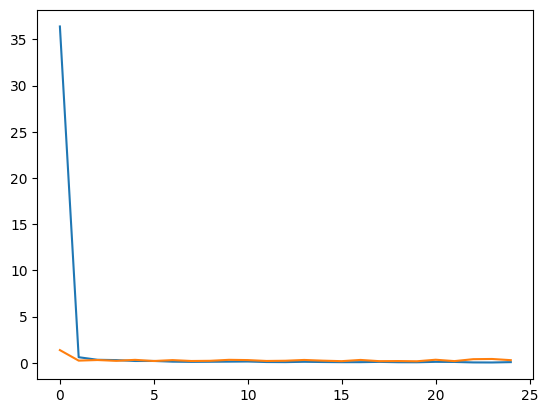

In [14]:
plt.plot(model.history.history['loss'])
plt.plot(model.history.history['val_loss'])

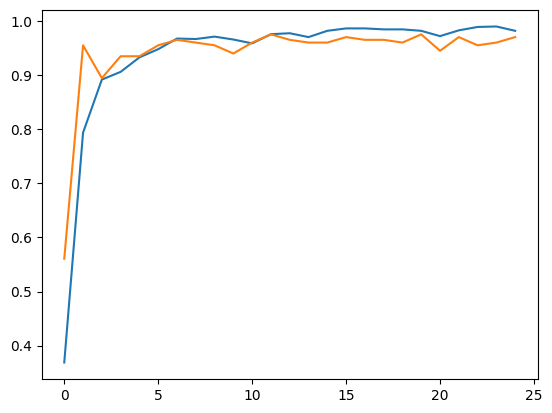

In [15]:
plt.plot(model.history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])

In [16]:
import cv2
import numpy as np
import os

database = {}

for person in os.listdir('dataset_ready'):

    person_path = f'dataset_ready/{person}'
    
    if not os.path.isdir(person_path):
        continue

    encodings = []

    for img_name in os.listdir(person_path):
        img = cv2.imread(f"{person_path}/{img_name}")

        if img is None:
            continue

        img = cv2.resize(img, (100,100))
        img = img.flatten() / 255.0

        encodings.append(img)

    database[person] = encodings

In [17]:
def recognize(img_path):

    img = cv2.imread(img_path)

    if img is None:
        print("Ошибка")
        return

    img = cv2.resize(img, (100,100))
    img = img.flatten() / 255.0

    best_match = None
    min_dist = 999

    for person, enc_list in database.items():

        for enc in enc_list:

            dist = np.linalg.norm(enc - img)

            if dist < min_dist:
                min_dist = dist
                best_match = person

    print("Distance:", min_dist)

    if min_dist < 5:   # подбирается
        print("Найден:", best_match)
        return best_match
    else:
        print("Unknown")
        return "Unknown"

In [18]:
recognize("dataset_ready/Albert Galstyan/img_0.jpg")

Distance: 0.0
Найден: Albert Galstyan


'Albert Galstyan'

In [19]:

model.save("model.keras")


import pickle
with open("labels.pkl", "wb") as f:
    pickle.dump(labels, f)

print("ВСЕ СОХРАНЕНО")

ВСЕ СОХРАНЕНО
